# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [1]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  9743k      0 --:--:--  0:01:32 --:--:-- 12.6M


In [2]:
!rm SUSY.csv

rm: cannot remove 'SUSY.csv': No such file or directory


In [3]:
!gunzip SUSY.csv.gz

In [4]:
ls -lh

total 2.3G
-rw-rw-r-- 1 ashish ashish  32K Mar 27 21:01 Lab.7.Solutions.ipynb
-rw-rw-r-- 1 ashish ashish 390K Mar 19 14:11 Lab.7.ipynb
-rw-rw-r-- 1 ashish ashish 5.9M Mar 19 14:11 Lab.7.pdf
-rw-rw-r-- 1 ashish ashish    0 Mar 25 16:56 SUSY-small.csv
-rw-rw-r-- 1 ashish ashish 2.3G Mar 27 21:01 SUSY.csv


The data is provided as a comma separated file.

In [5]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [6]:
!ls -lh

total 2.3G
-rw-rw-r-- 1 ashish ashish  32K Mar 27 21:01 Lab.7.Solutions.ipynb
-rw-rw-r-- 1 ashish ashish 390K Mar 19 14:11 Lab.7.ipynb
-rw-rw-r-- 1 ashish ashish 5.9M Mar 19 14:11 Lab.7.pdf
-rw-rw-r-- 1 ashish ashish    0 Mar 25 16:56 SUSY-small.csv
-rw-rw-r-- 1 ashish ashish 2.3G Mar 27 21:01 SUSY.csv


We see that we have 5 million datapoints.

In [7]:
!wc -l SUSY.csv

5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [8]:
!head -500000 SUSY.csv > SUSY-small.csv

In [9]:
ls -lh

total 2.5G
-rw-rw-r-- 1 ashish ashish  32K Mar 27 21:01 Lab.7.Solutions.ipynb
-rw-rw-r-- 1 ashish ashish 390K Mar 19 14:11 Lab.7.ipynb
-rw-rw-r-- 1 ashish ashish 5.9M Mar 19 14:11 Lab.7.pdf
-rw-rw-r-- 1 ashish ashish 228M Mar 27 21:01 SUSY-small.csv
-rw-rw-r-- 1 ashish ashish 2.3G Mar 27 21:01 SUSY.csv


In [10]:
! wc -l SUSY-small.csv

500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [11]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [12]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [13]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [14]:
FeatureNames

['M_TR_2',
 'M_Delta_R',
 'MET_rel',
 'R',
 'axial_MET',
 'MT2',
 'M_R',
 'S_R',
 'dPhi_r_b',
 'cos_theta_r1']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [16]:
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [17]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,0.0,0.719035,1.091879,0.291540,1.205962,-1.599117,-1.139445,0.424546,1.154849,0.637185,-0.091178,1.972156,0.697028,0.313636,0.988602,1.981573,0.744828,1.095080,0.006546
499996,1.0,0.910016,-0.364544,-0.777120,0.543648,-0.910632,-1.723707,2.864673,1.458272,2.176558,-0.590911,0.673695,1.662140,2.189362,1.195041,0.910815,1.181893,1.252362,0.826035
499997,1.0,0.842954,0.332476,-1.048564,1.347989,0.320496,-0.666358,0.450433,-0.411872,0.293407,0.630491,0.859920,0.403371,0.416258,0.591989,0.372003,0.716788,0.366991,0.265798
499998,0.0,1.370760,-1.162912,0.893499,2.118091,1.248496,-0.887211,0.164659,0.316840,0.215165,0.280418,3.087083,0.526929,0.151467,0.308067,3.098183,0.233042,0.876216,0.000593


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [18]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


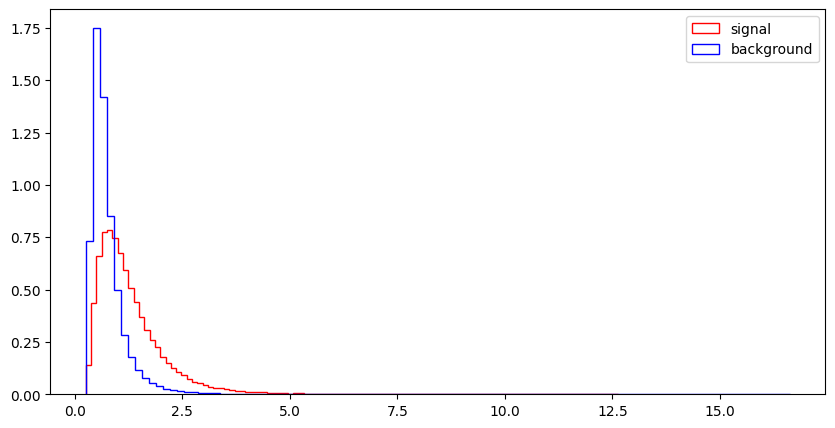

l_1_eta


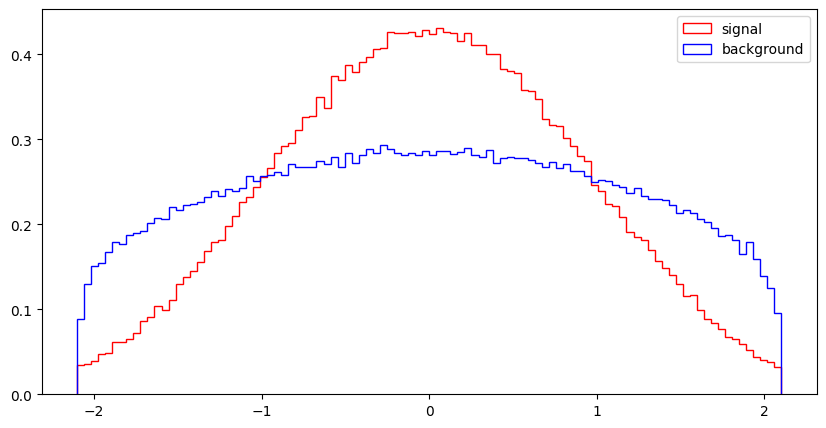

l_1_phi


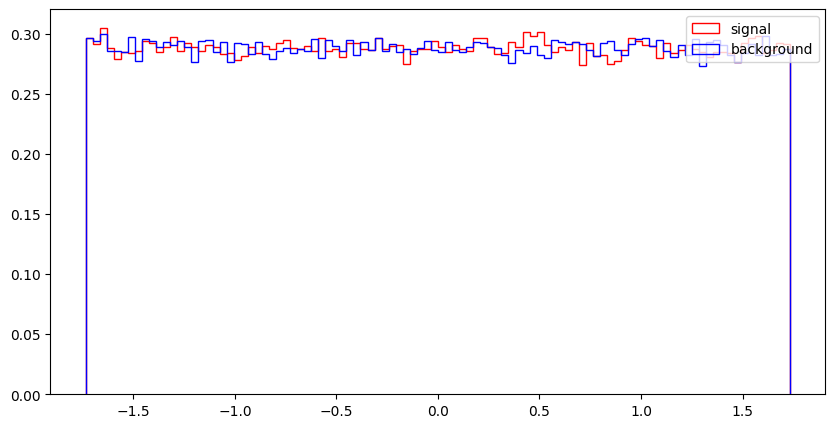

l_2_pT


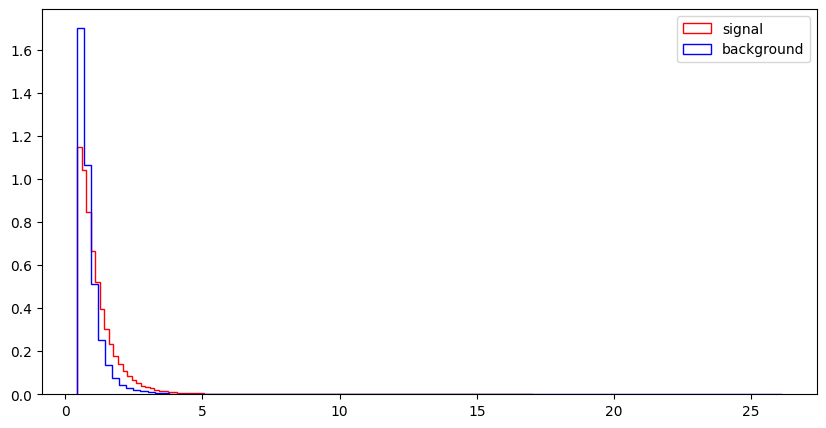

l_2_eta


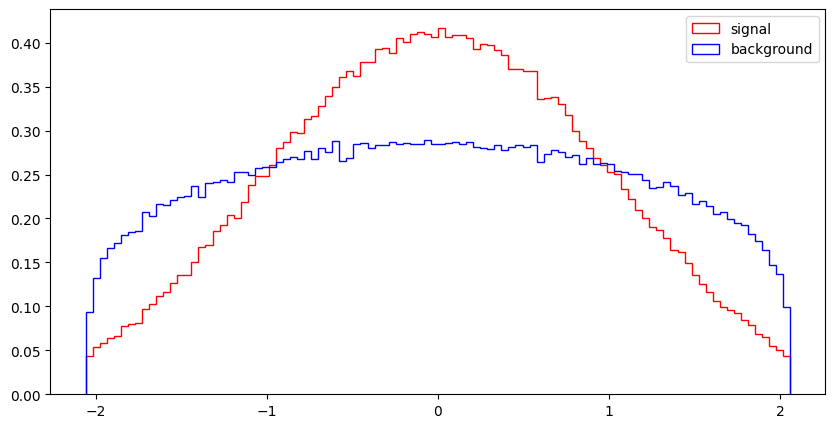

l_2_phi


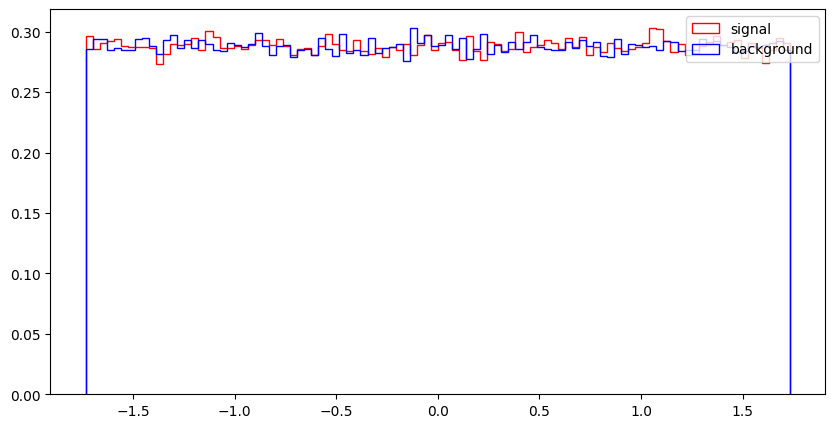

MET


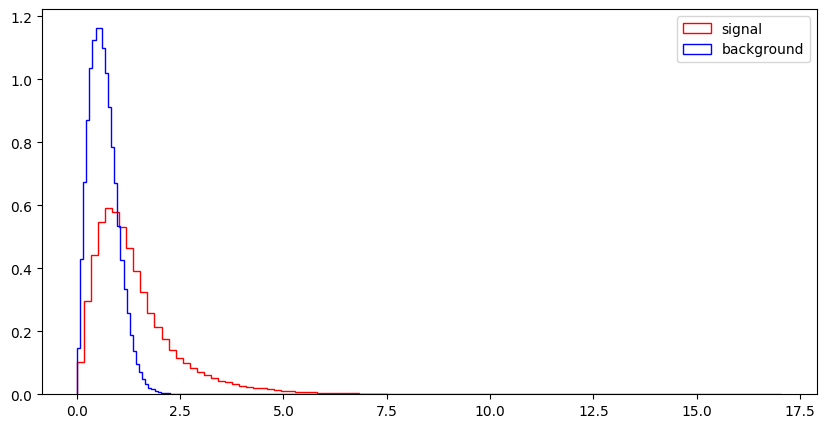

MET_phi


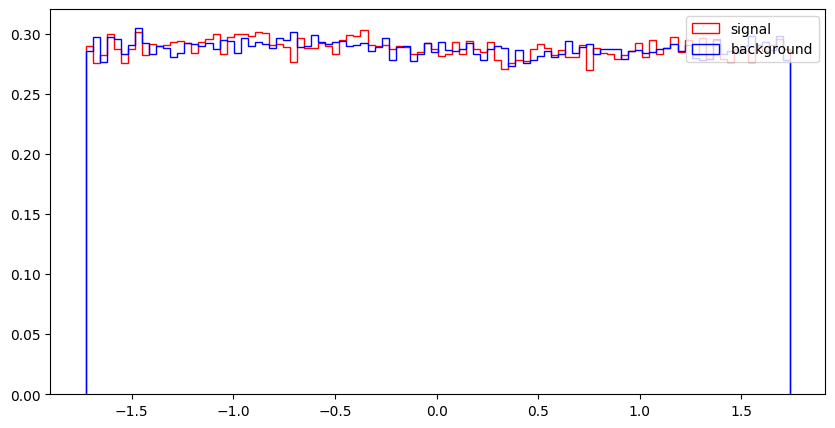

MET_rel


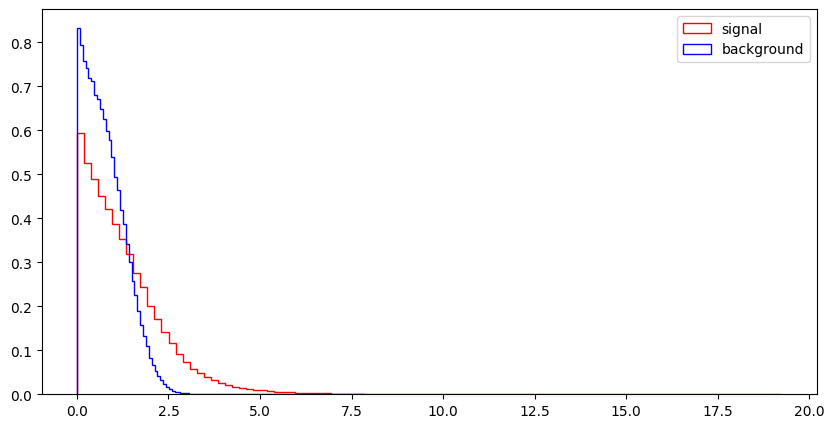

axial_MET


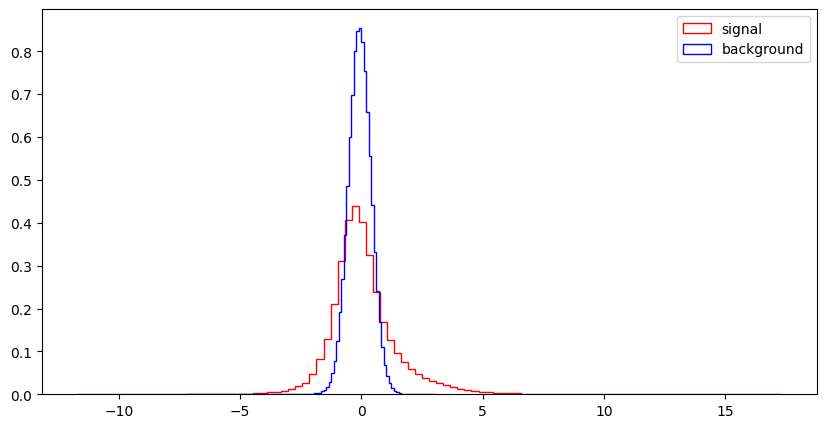

M_R


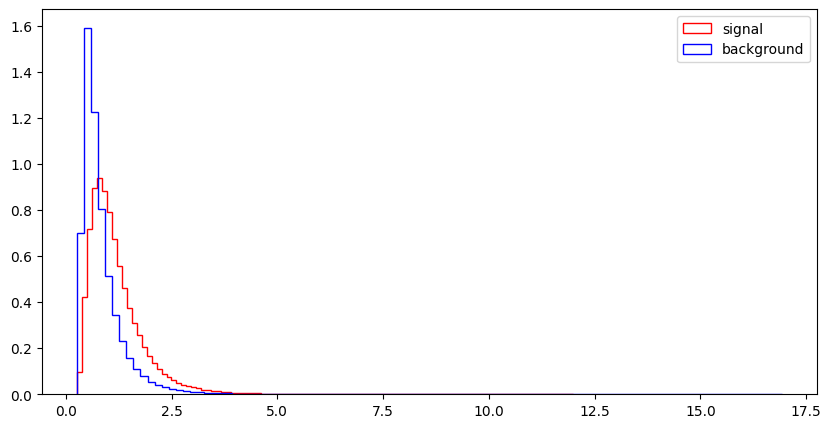

M_TR_2


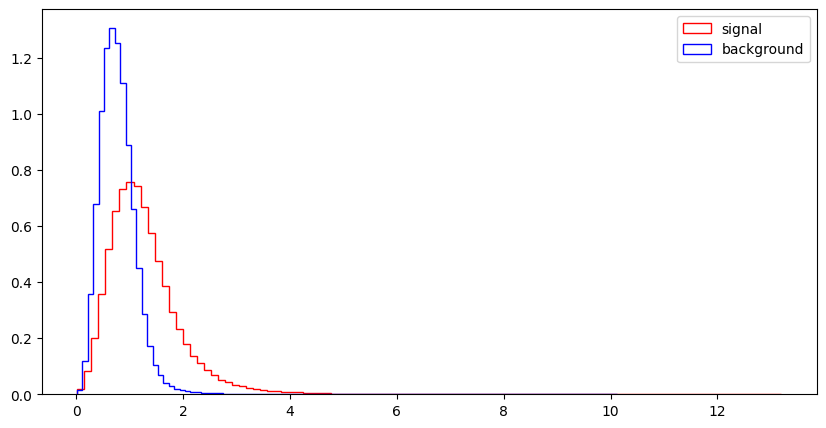

R


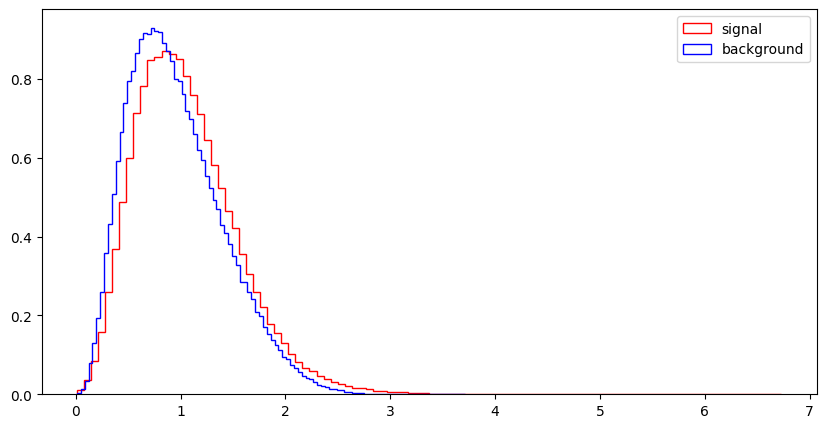

MT2


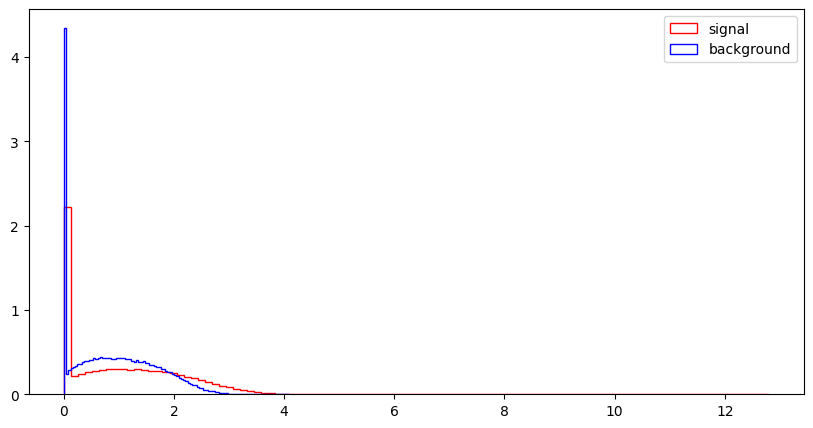

S_R


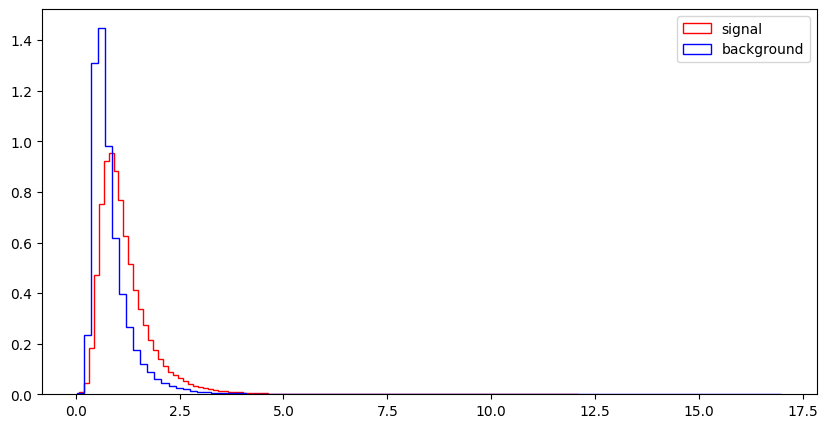

M_Delta_R


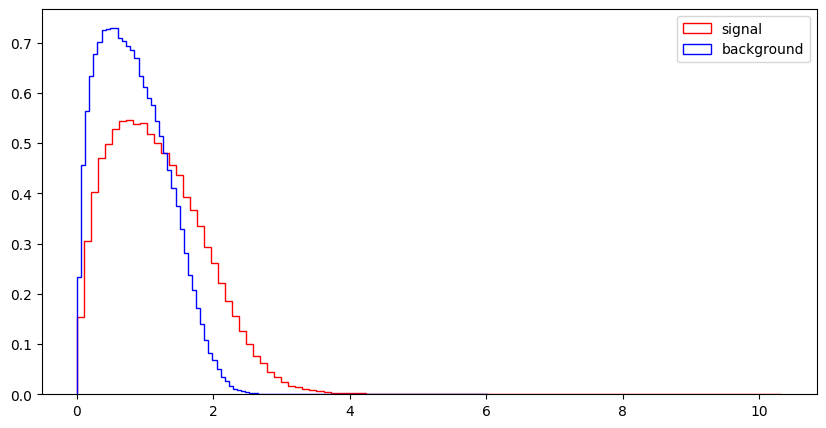

dPhi_r_b


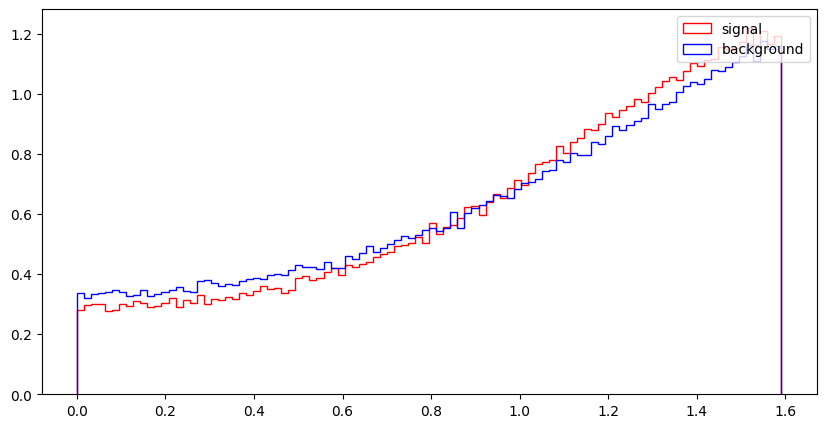

cos_theta_r1


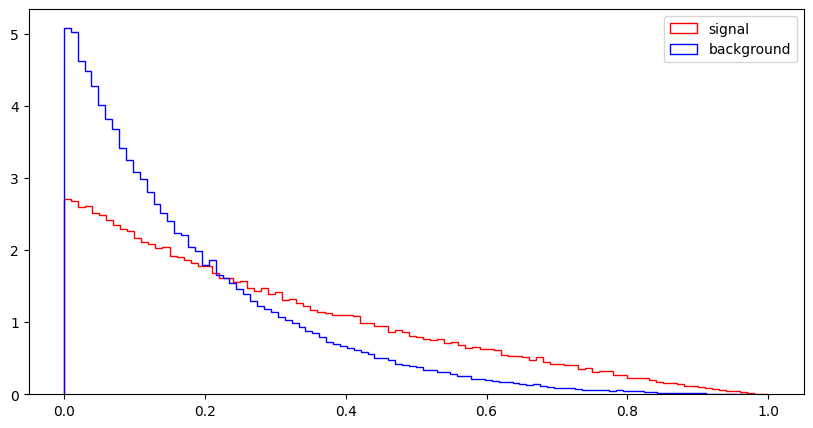

In [19]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

`NOTE:` For figure 5 (of the paper) I only choose 3 variables that were present in both dataset and the plot displayed in the paper.

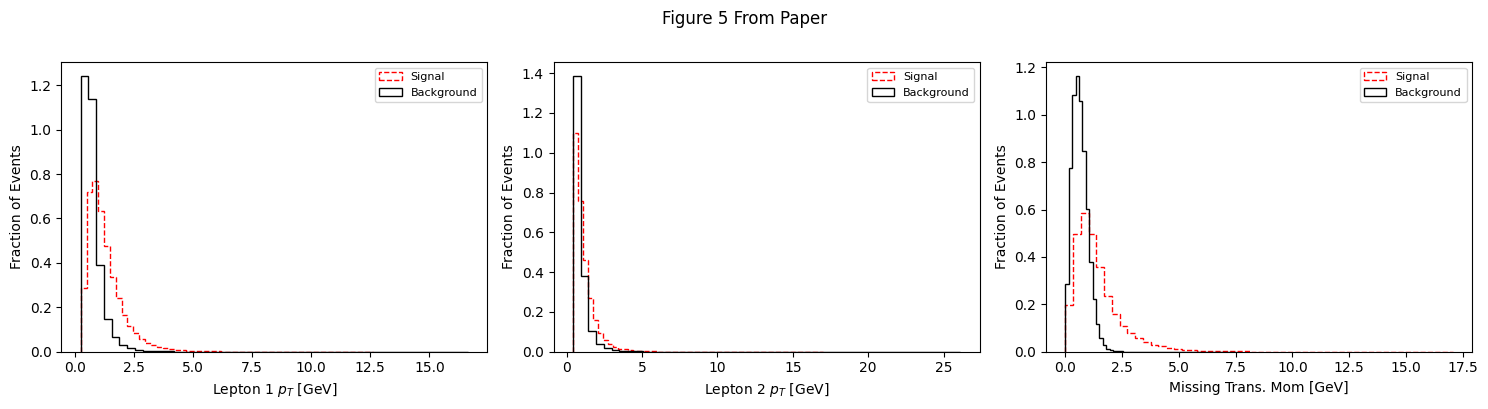

In [32]:
#Create a variable that holds the variable name with its corresponding desired x-label
#Label name supports LaTeX math notation: (wrapped in $...$) for formatted axis titles.
plot_vars= [
    ("l_1_pT", "Lepton 1 $p_T$ [GeV]"),
    ("l_2_pT", "Lepton 2 $p_T$ [GeV]"),
    ("MET",    "Missing Trans. Mom [GeV]")
]    #First element in each tuple is the variable and second element is the label for that variable

fig, axes= plt.subplots(1,3, figsize=(15,4))    #Creates a grid of subplots (1 rows and 3 columns)

#Loops for each subplot with its corresponding (variable, label) pair
for ax, (var, xlabel) in zip(axes, plot_vars):    #zip pairs each axis with corresponding (variable, label)
    
    #Red dash-lined Density Histogram with 50 bins for corresponding variable when signal
    ax.hist(df_sig[var], bins=50, density= True, histtype='step', color='red', label='Signal', linestyle='--')
    
    #Black lined Density Histogram with 50 bins for corresponding variable when Background
    ax.hist(df_bkg[var], bins=50, density= True, histtype='step', color='black', label='Background')
    ax.set_xlabel(xlabel)    #Sets label for x-axis (second element of every tuple in plot_var)
    ax.set_ylabel("Fraction of Events")   #Set label for y-axis
    ax.legend(fontsize=8)     #Displays colors represenration for the categories
plt.suptitle("Figure 5 From Paper", y=1.01)
plt.tight_layout()   #Prevents title and plot overlapping
plt.show()    #Displays the plot

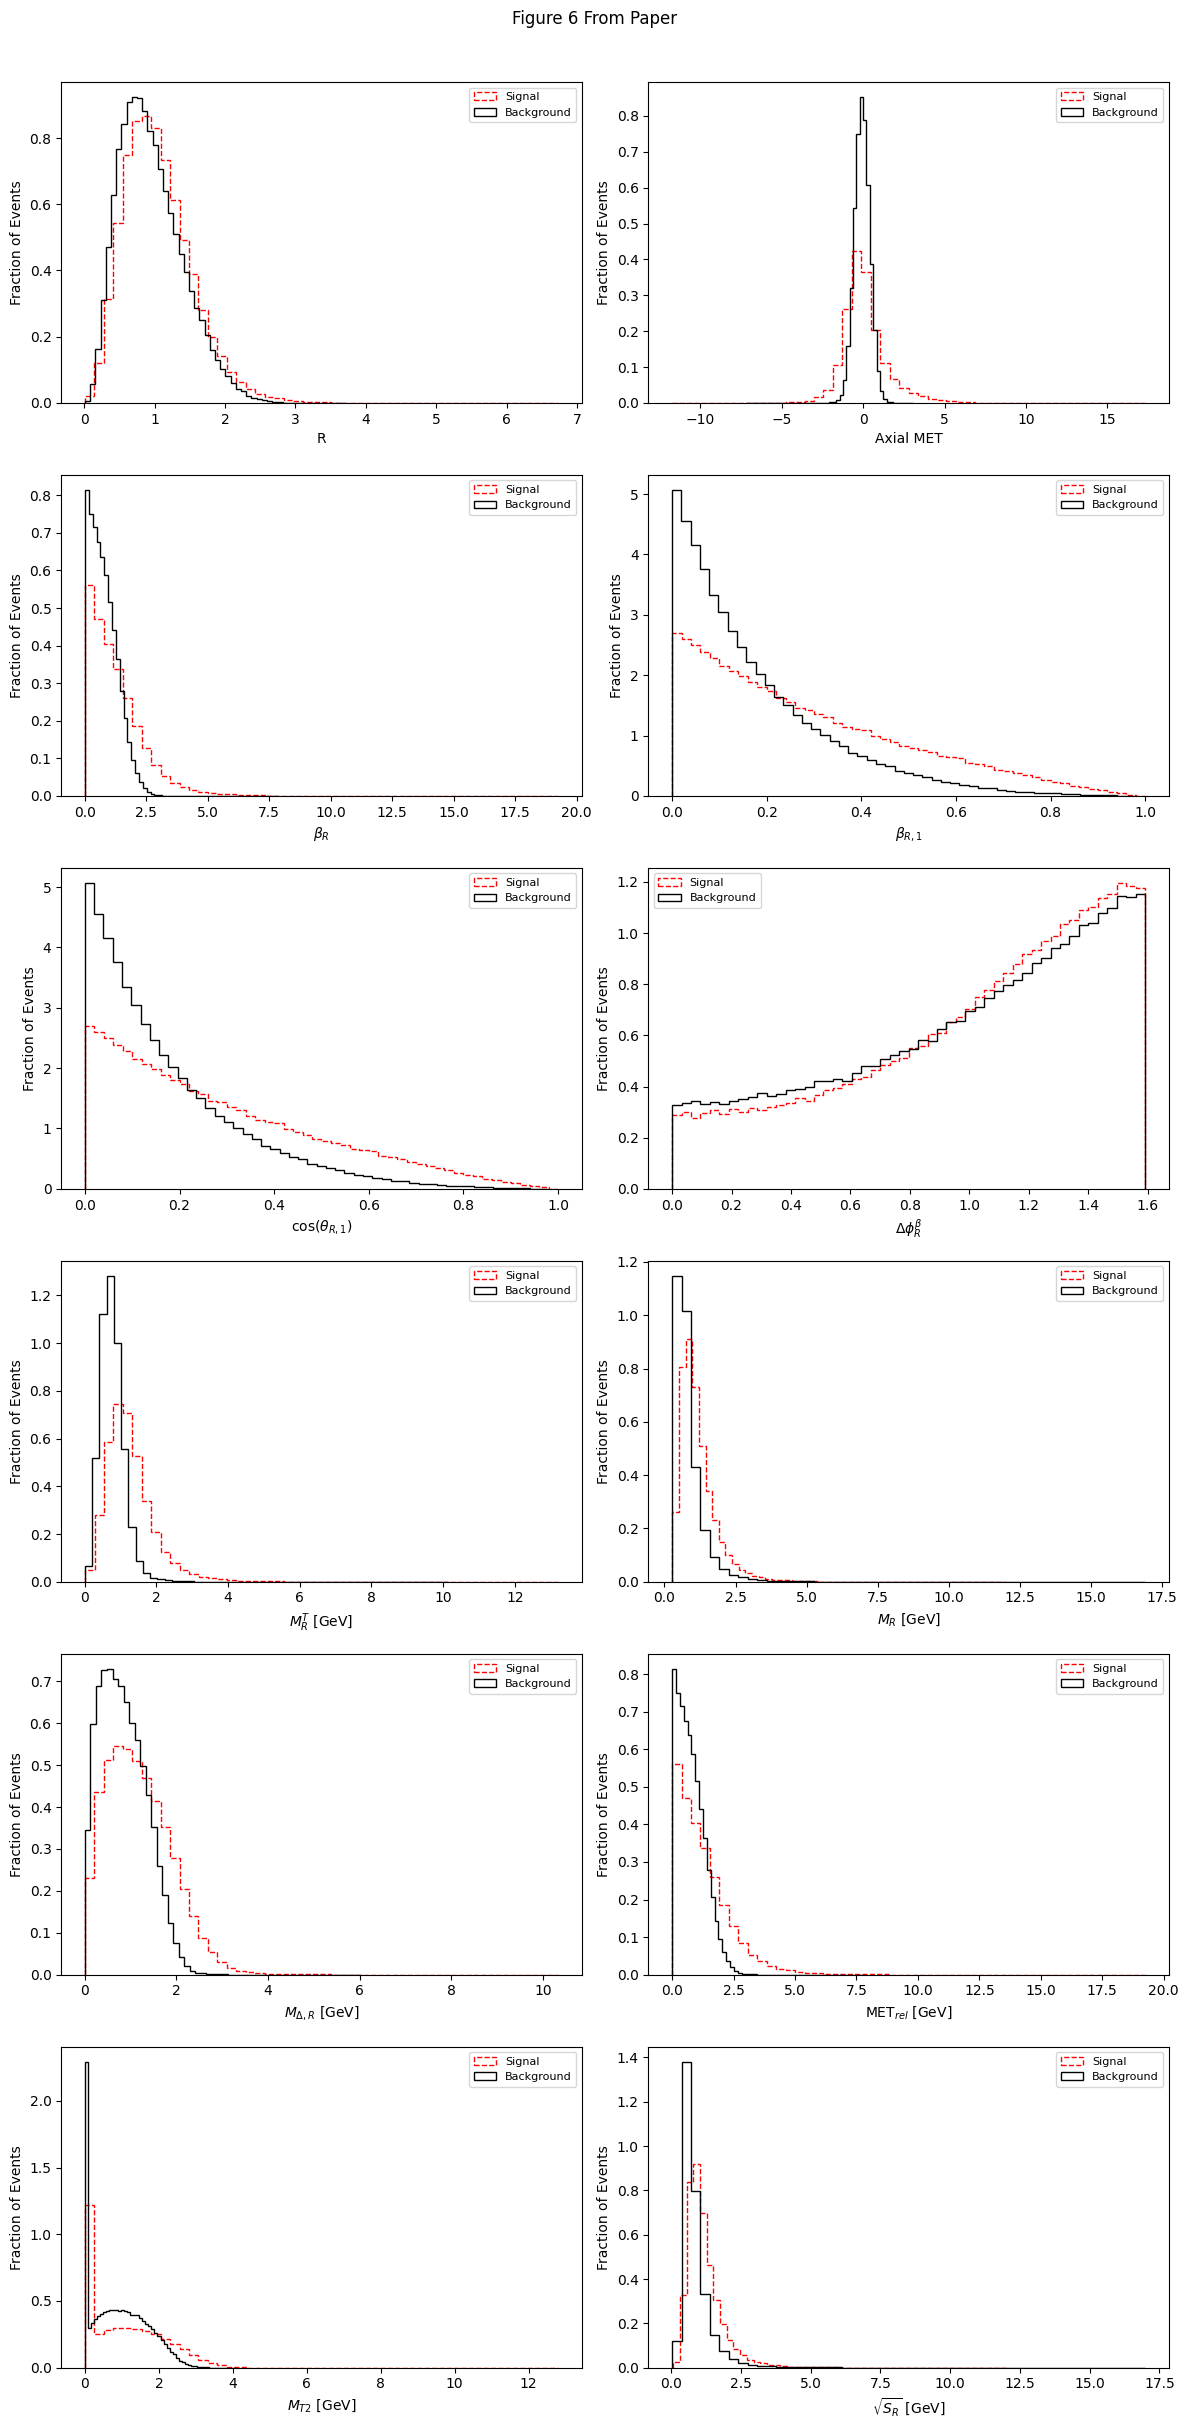

In [33]:
# Each tuple is (dataframe_column, desired_label)
#Label name supports LaTeX math notation: (wrapped in $...$) for formatted axis titles.
plot_vars_fig6 = [
    ("R",           "R"),
    ("axial_MET",   "Axial MET"),
    ("MET_rel",     "$\\beta_R$"),
    ("cos_theta_r1","$\\beta_{R,1}$"),
    ("cos_theta_r1","$\\cos(\\theta_{R,1})$"),
    ("dPhi_r_b",    "$\\Delta\\phi_R^{\\beta}$"),
    ("M_TR_2",      "$M_R^T$ [GeV]"),
    ("M_R",         "$M_R$ [GeV]"),
    ("M_Delta_R",   "$M_{\\Delta,R}$ [GeV]"),
    ("MET_rel",     "MET$_{rel}$ [GeV]"),
    ("MT2",         "$M_{T2}$ [GeV]"),
    ("S_R",         "$\\sqrt{S_R}$ [GeV]"),
]

#Creates a grid of subplots (6 rows and 2 columns)
fig, axes = plt.subplots(6, 2, figsize=(12, 24))
axes = axes.flatten()    #Converts 2D grid to 1D grid for easier looping (single loop instead of nested)

#Loops for each subplot with its corresponding (variable, label) pair
for ax, (var, xlabel) in zip(axes, plot_vars_fig6):    #zip pairs each axis with corresponding (variable, label)
    
    #Red dash-lined Density Histogram with 50 bins for corresponding variable when signal
    ax.hist(df_sig[var],     bins=50, density=True, histtype='step', linestyle='dashed', color='red',   label='Signal')
    
    #Black lined Density Histogram with 50 bins for corresponding variable when Background
    ax.hist(df_bkg[var], bins=50, density=True, histtype='step', color='black', label='Background')
    
    ax.set_xlabel(xlabel)    #Set x-label
    ax.set_ylabel("Fraction of Events")    #set y-label
    ax.legend(fontsize=8)    #Displays legend with font-size of 8 units

plt.suptitle("Figure 6 From Paper", y=1.01)
plt.tight_layout()
plt.show()    #Display plot

`NOTE:` AI was used for the better representation of the labels using the **LaTeX math format**.

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

In [40]:
# Part a


#Create a function that takes dataframe, variable_names, and title of the plot and plots the corresponding pair-plot.
def pair_plot(df, varnames, title="Pair Plot"):
    n= len(varnames)    # number of variables passed in the argument
    
    #Creates a grid of subplots (n rows and n columns), each of size 2.5*2.5
    fig, axes= plt.subplots(n, n, figsize=(2.5*n, 2.5*n))
    
    #Provide the title for the plot with a font size of 14 units
    fig.suptitle(title, fontsize=16, y=1.01)    #y=1.01 sets the title slightly above its default value preventing the overlapping of plot and title

    for i, var_y in enumerate(varnames):    #Loop through variable with its corresponding index
        for j, var_x in enumerate(varnames):    #Loop through same variable with its index  
            ax= axes[i][j]    #subplot form 2-D sxes, at ith rows and jth column.
            
            #If the subplot is in leading diagonal (i==j) create a 1-D histogram for the variable for both 'signal' and 'background'
            if i==j:
                ax.hist(df_sig[var_x], bins=30, density=True, histtype='step', color='red', linestyle='--', label='Signal')
                ax.hist(df_bkg[var_x], bins=30, density=True, histtype='step', color='black', label='Background')
                ax.set_xlabel(var_x, fontsize=7)
                
            #Else, create a 2-D histogram for each variable plotted against one aother.
            else:
                ax.hist2d(df[var_x], df[var_y], bins=30, cmap="Blues")
                ax.set_xlabel(var_x, fontsize=7)
                ax.set_ylabel(var_y, fontsize=7)


    plt.tight_layout()
    plt.show()

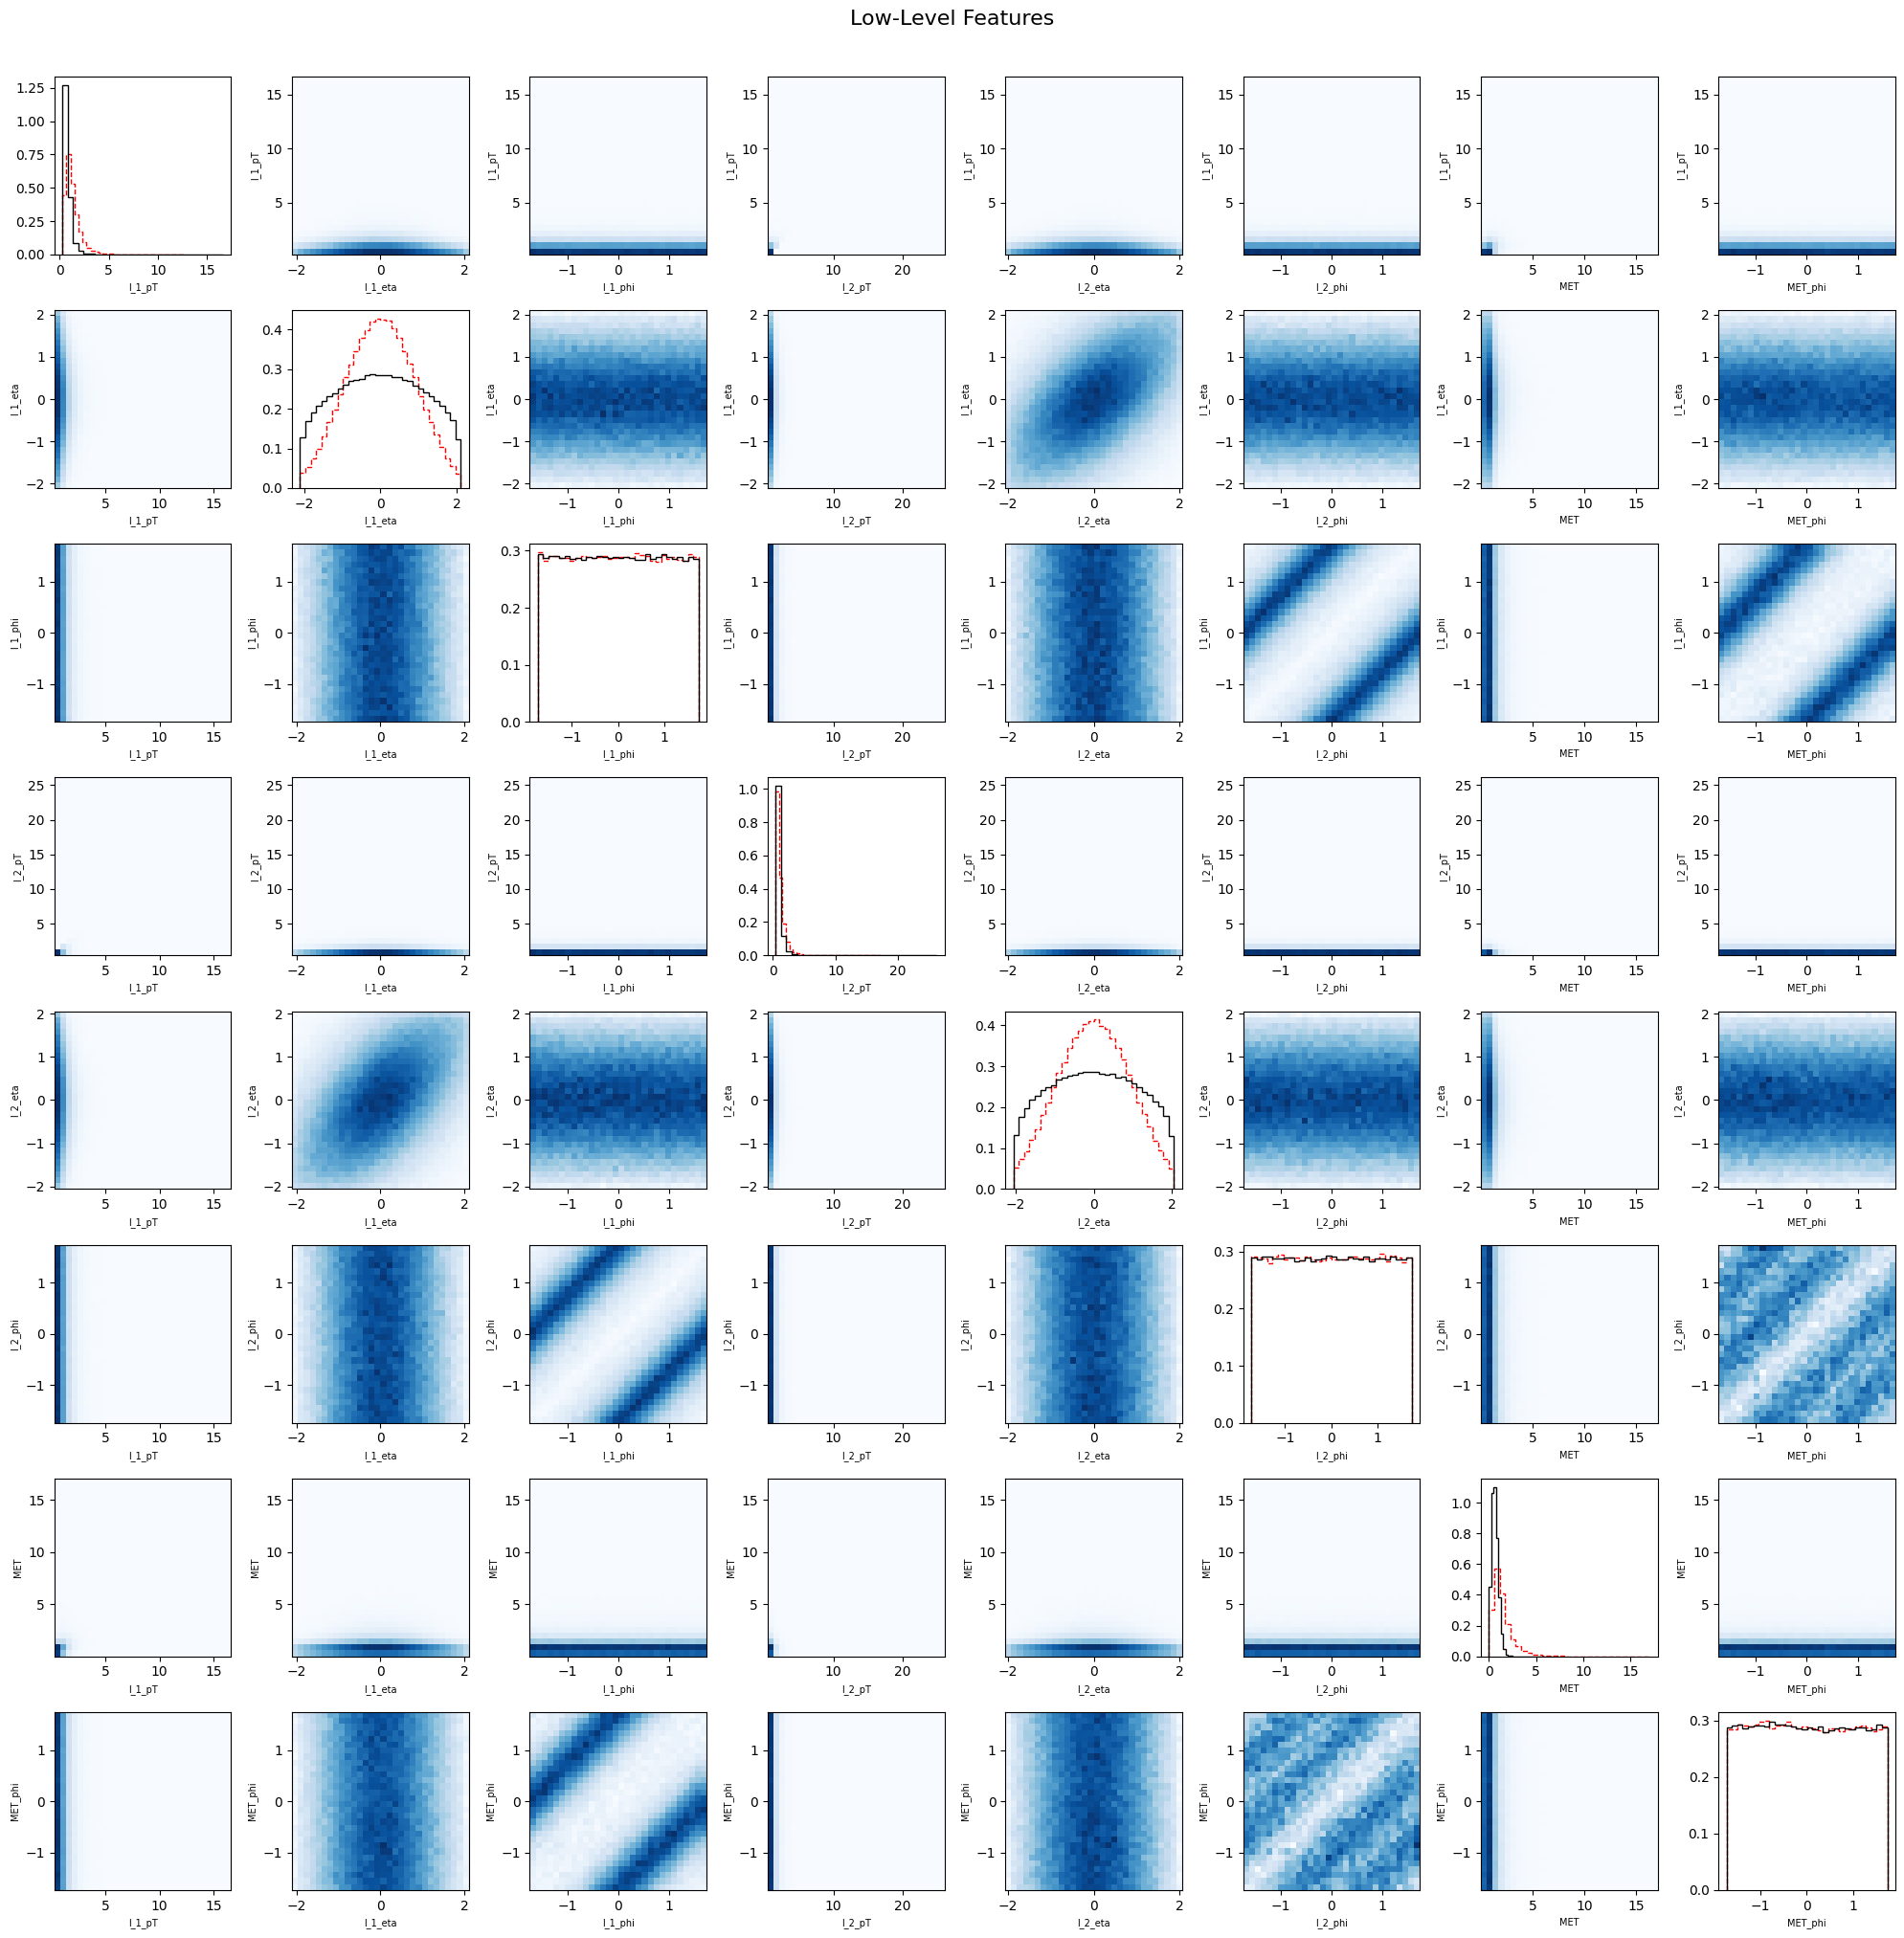

In [42]:
# For RawNames
pair_plot(df, RawNames, title="Low-Level Features")

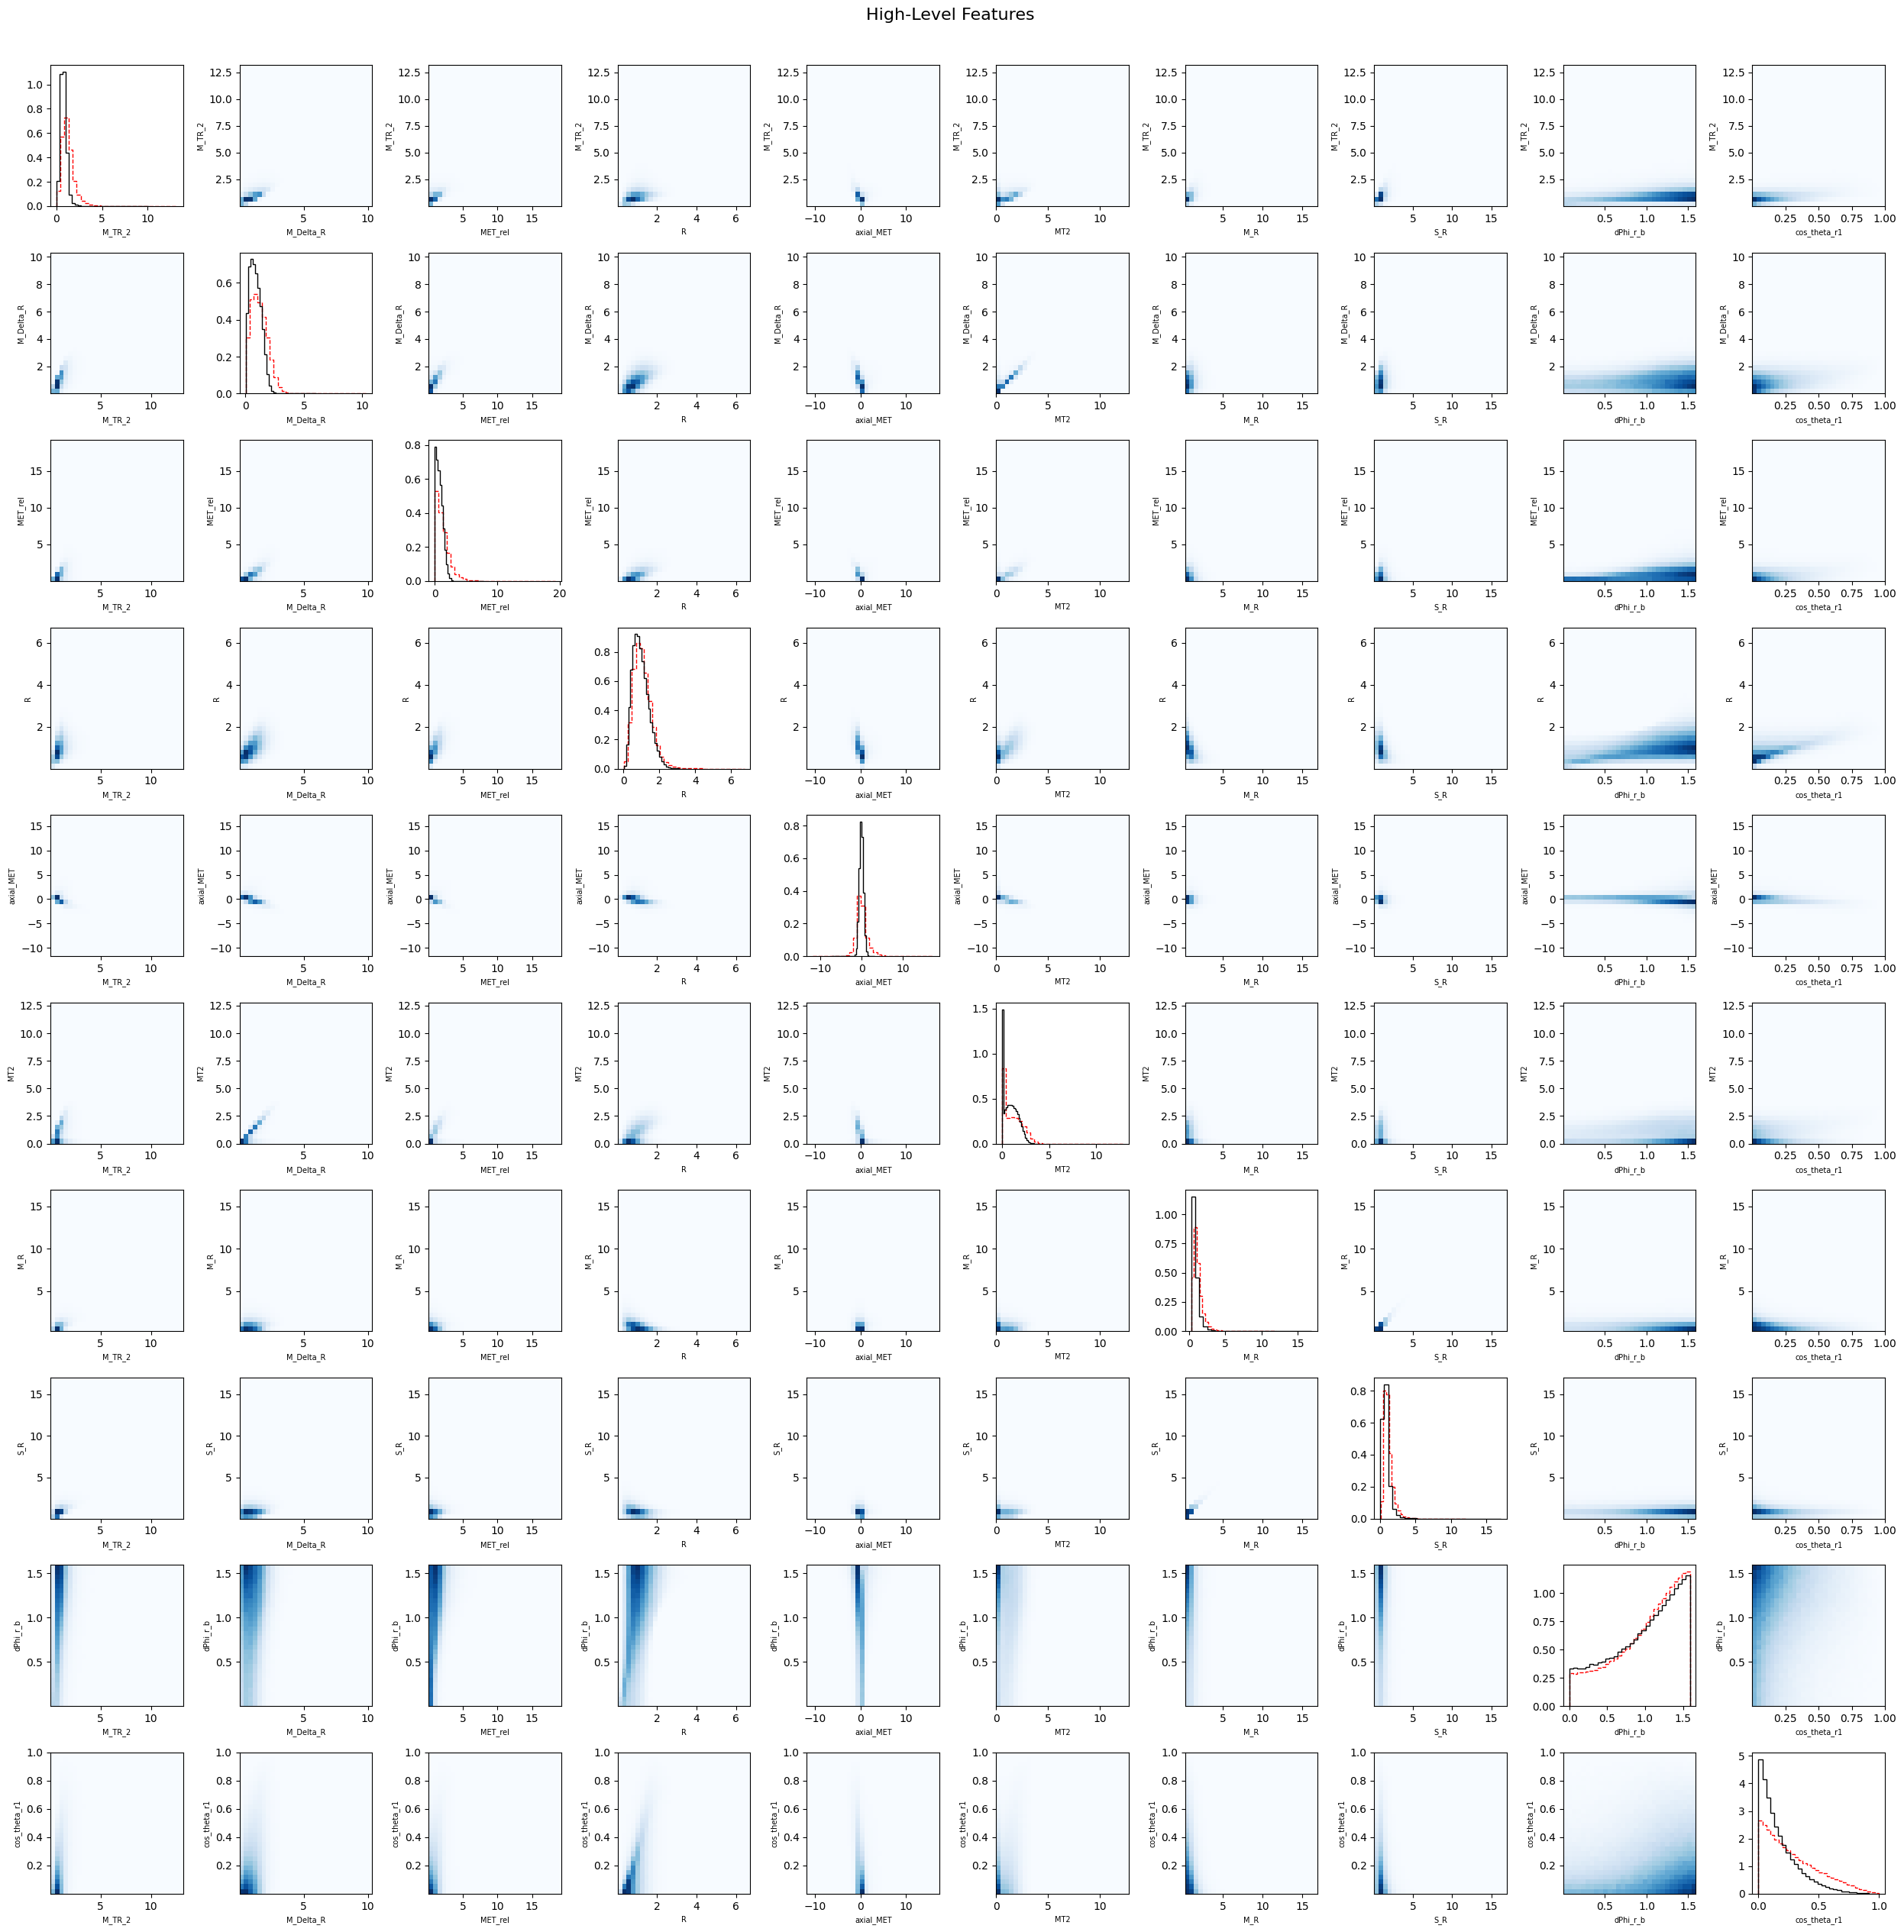

In [43]:
#For Feature Name:
pair_plot(df, FeatureNames, title="High-Level Features")

In [44]:
# Part b

#Create a function that creates a plot grid where
#1. diagonal cells show normalized 1D histogram for both singal avd background
#2. Other than diagonal cells show 2D heatmaps of the combined dataset for each variable pair

def pair_plot_fast(df, varnames, title="pair Plot"):    #Takes dataframe, list of column_names, and plot title as argument
    n=len(varnames)
    
    #Creates a grid of subplots (n rows and n columns), each of size 2.5*2.5 
    fig, axes = plt.subplots(n, n, figsize=(2.5 * n, 2.5 * n))
    
    #Provide the title for the plot with a font size of 14 units
    fig.suptitle(title, fontsize=16, y=1.01)    #y=1.01 sets the title slightly above its default value preventing the overlapping of plot and title
    
    
    #Pre extract each variabl's value as NumPy arrays for all 3 dataset. 
    #This will help avoid the use of nested iteration, making the performance faster.
    sig_arrays= {v: df_sig[v].to_numpy() for v in varnames}   #Numpy array for signal dataset
    bkg_arrays= {v: df_bkg[v].to_numpy() for v in varnames}   #Numpy array for backrgounds
    all_arrays= {v: df[v].to_numpy() for v in varnames}       #Numpy array for both background and signal

    
    #Iterates over every cell in nxn grid
    for i, var_y in enumerate(varnames):   #i selects y-axis variable (row)
        for j, var_x in enumerate(varnames):    #j selects x-axis variable (column)
            ax= axes[i][j]
            
            #For leading diagonal (i==j), shows 1D density histogram to compare signal and background for corresponding variable
            if i==j:
                s_counts, s_edges= np.histogram(sig_arrays[var_x], bins=30, density=True)
                b_counts, b_edges= np.histogram(bkg_arrays[var_x], bins=30, density=True)
                
                #Draws step histograms where dashed red is for signal and solid black is for background.
                #s_edges[:-1] uses the left edge of each bin as the x position
                ax.step(s_edges[:-1], s_counts, color='red', linestyle='dashed', label='signal')
                ax.step(b_edges[:-1], b_counts, color='black', label='Bkg')
                ax.set_xlabel(var_x, fontsize=7)
            
            #Else, computer a 2D histrogram (n_x_bins, n_y_bins)
            else:
                h, xedges, yedges = np.histogram2d(all_arrays[var_x], all_arrays[var_y], bins=30)
                
                # Plot histogram as colored grid
                ax.pcolormesh(xedges, yedges, h.T, cmap="Blues")    # h.T so rows match y-axis
                ax.set_xlabel(var_x, fontsize=7)
                ax.set_ylabel(var_y, fontsize=7)
    plt.tight_layout()
    plt.show()

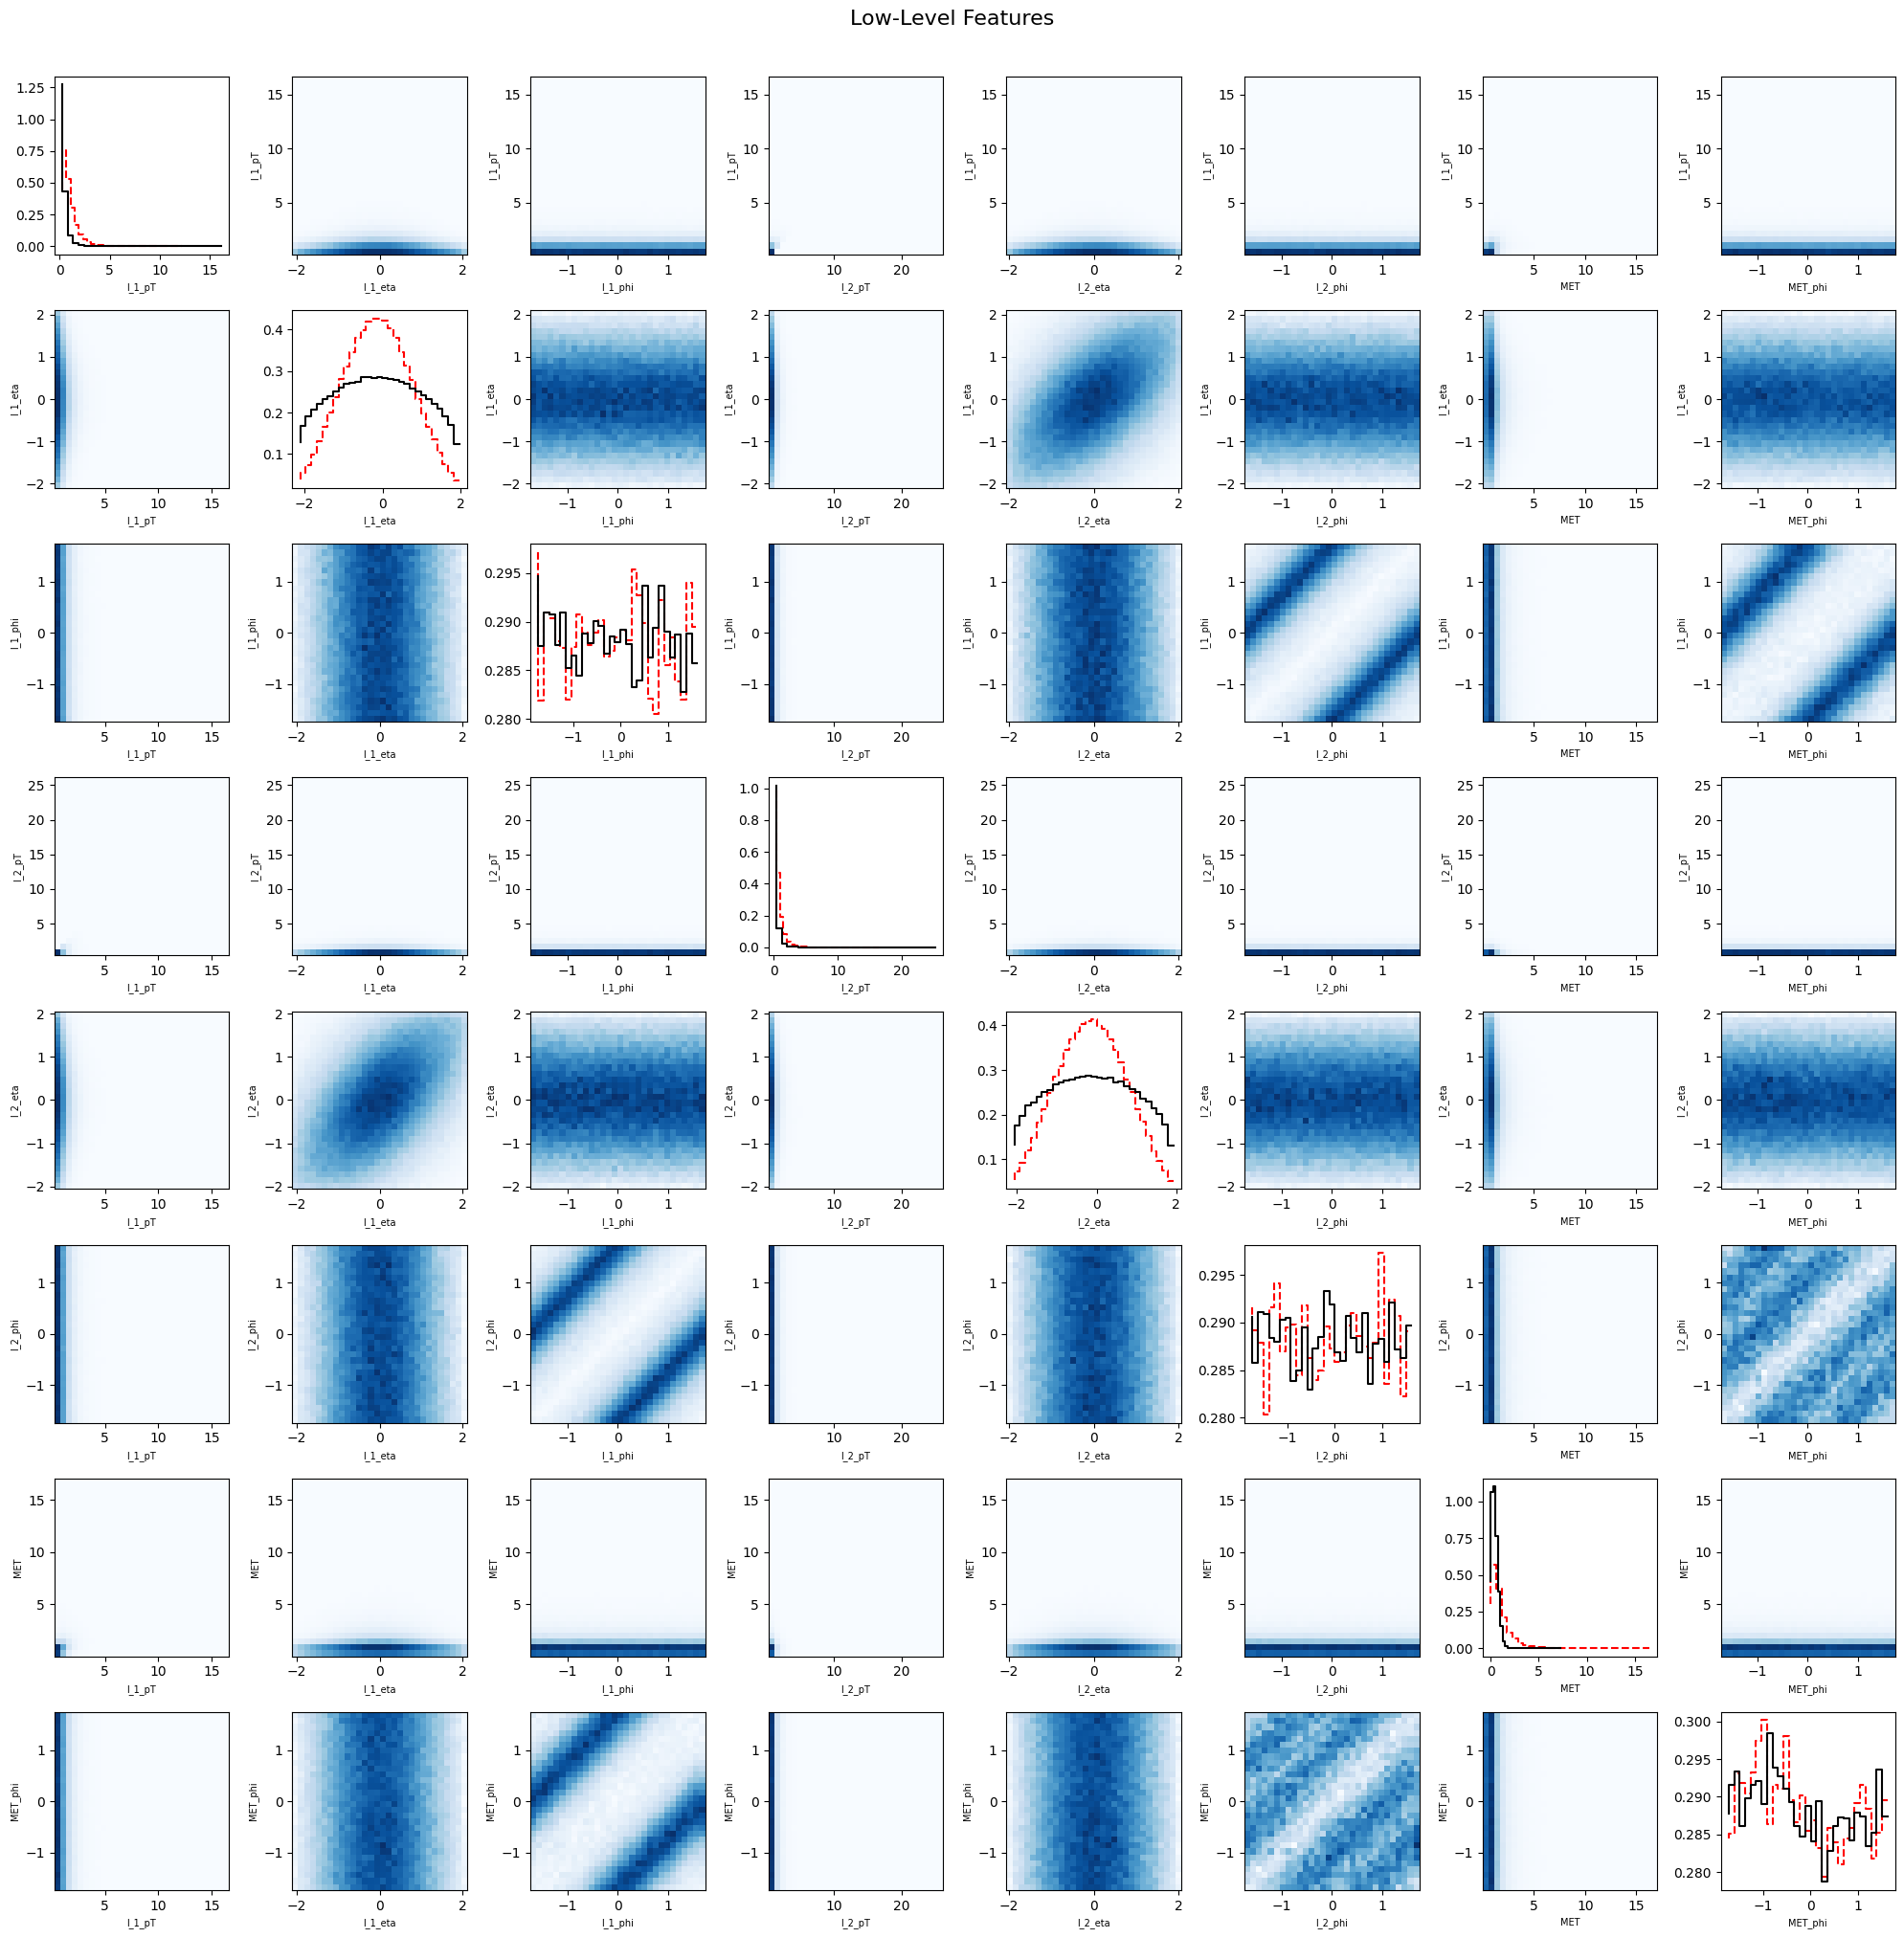

In [45]:
pair_plot_fast(df, RawNames, title="Low-Level Features")

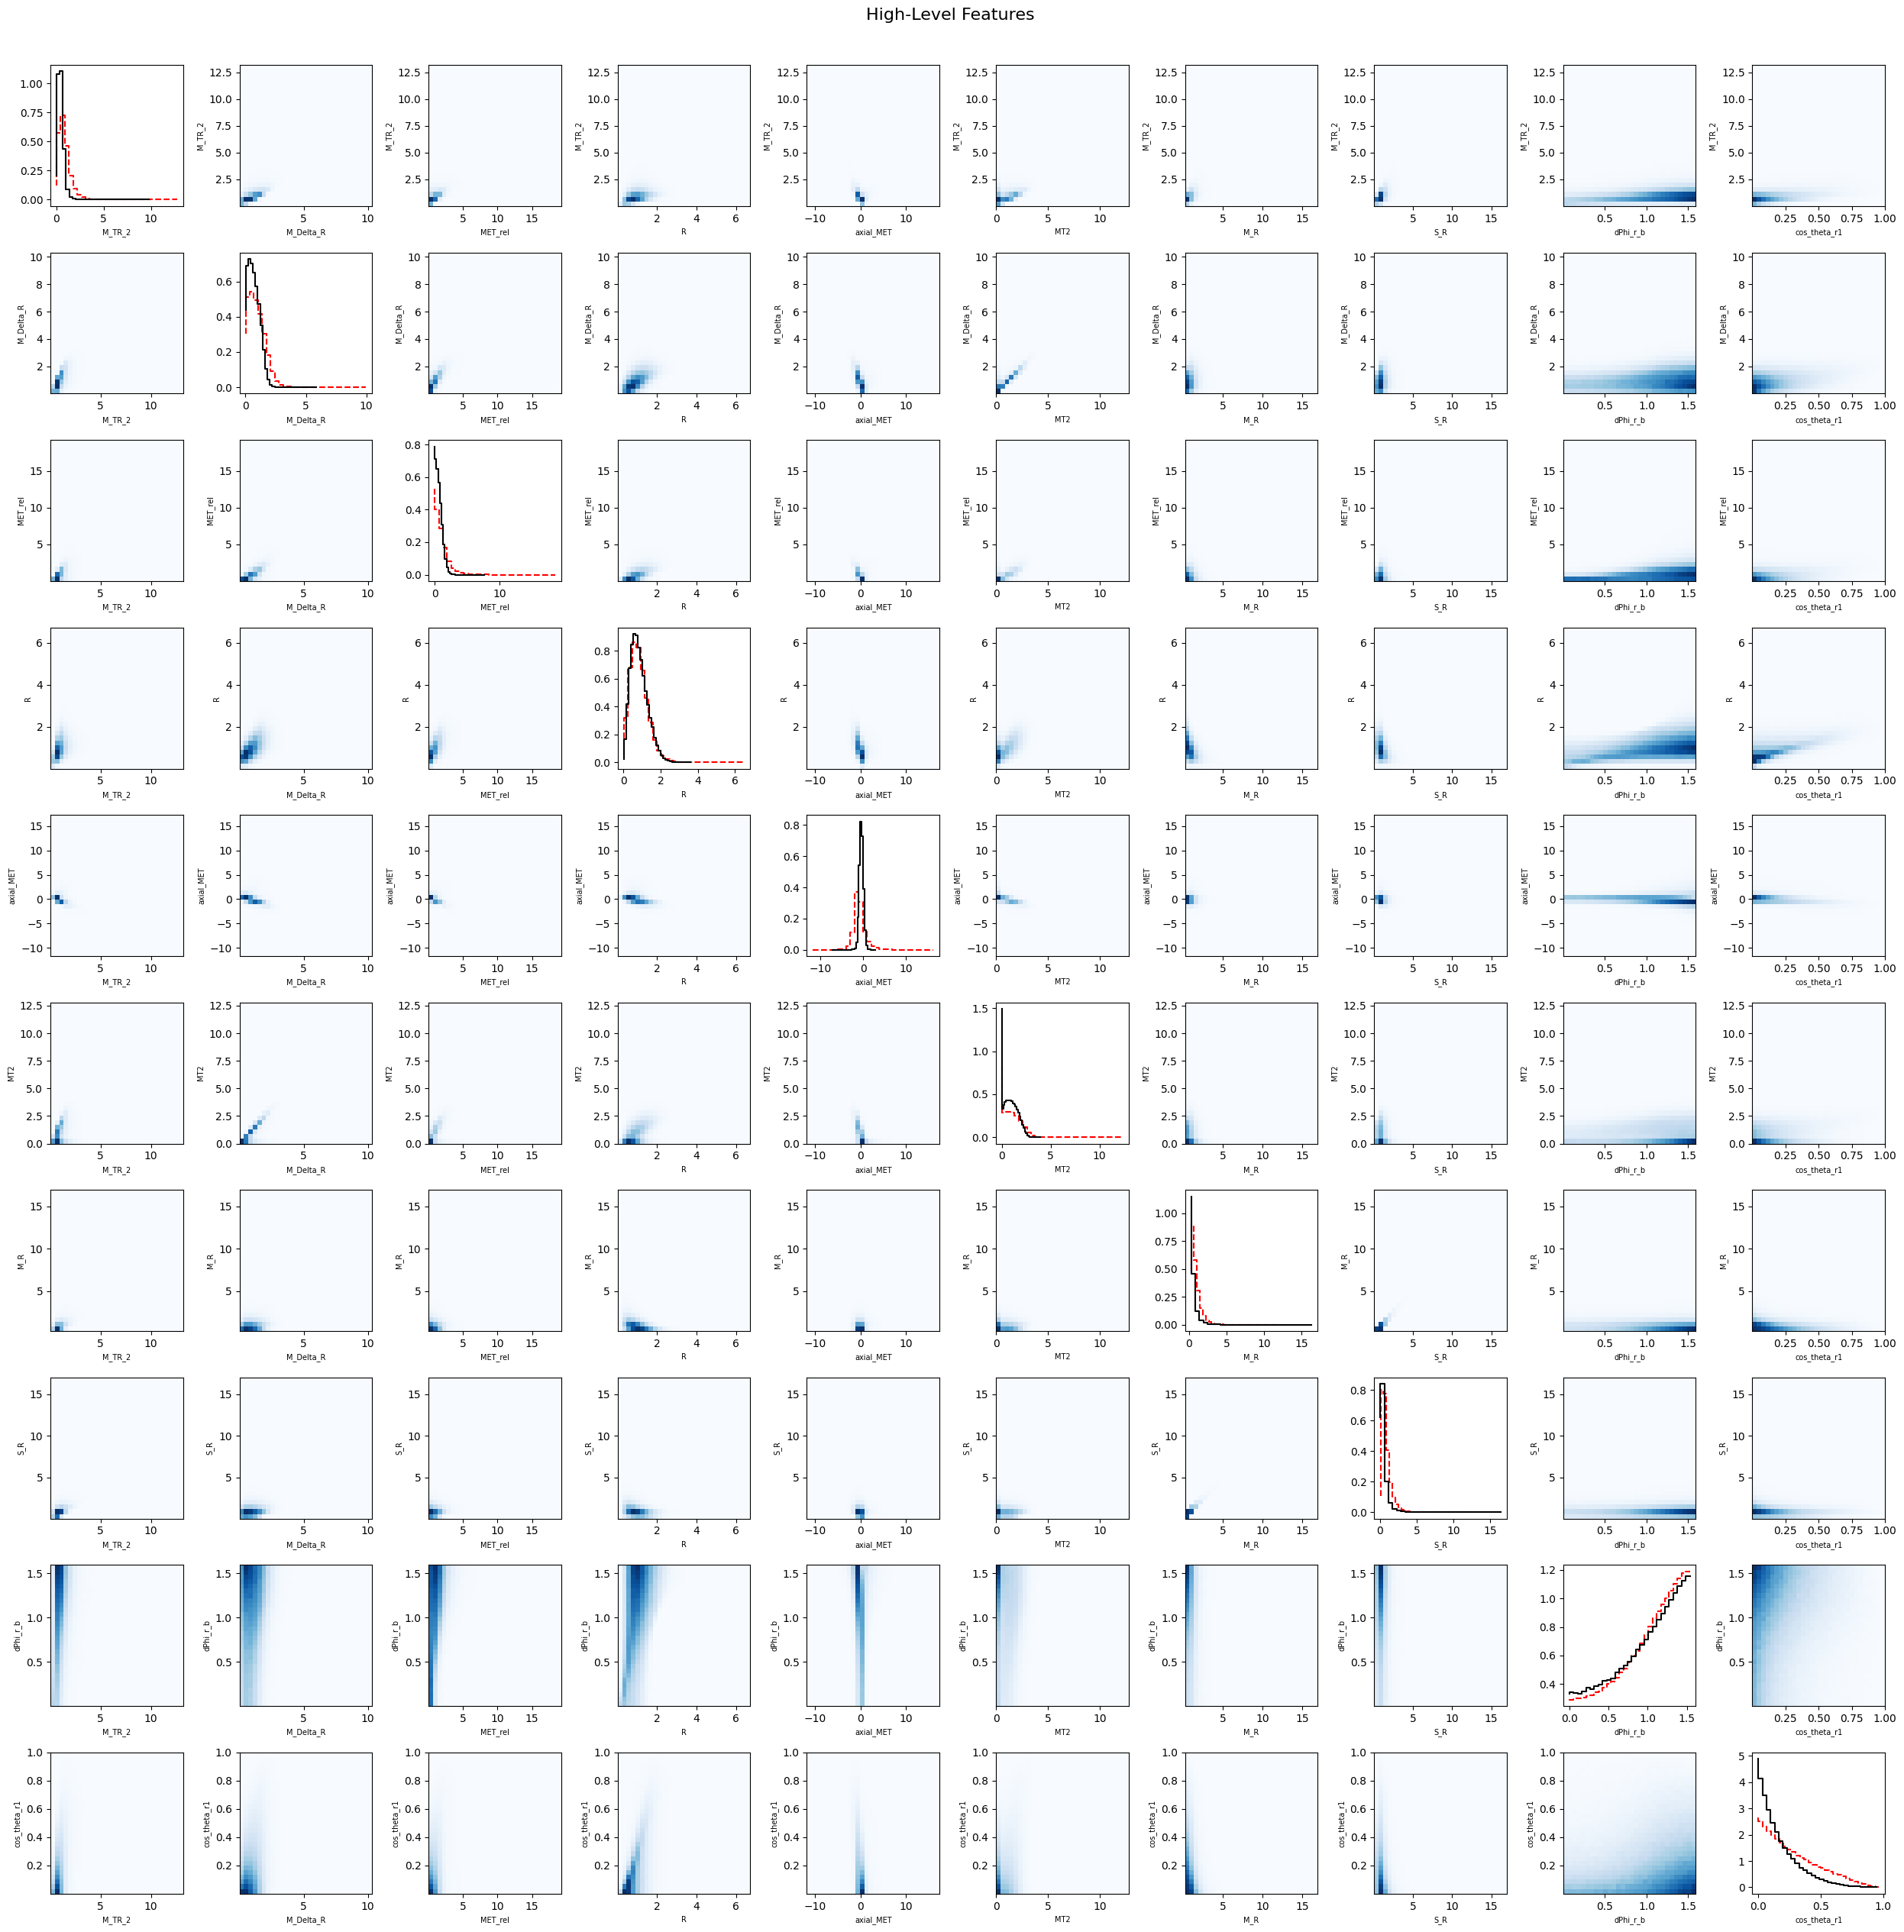

In [46]:
pair_plot_fast(df, FeatureNames, title="High-Level Features")

## Conclusion
### Low-level Features
- **l_1_pT** and **l_2_pT** show the best separation among low-level features. signal (red dashed) peaks sharply at low pT while background (black) has a heavier tail.
- **MET** also shows some separation, with signal decaying faster than background.
- **l_1_eta**, **l_2_phi**, and **MET_phi** show virtually **no separation**- both distributions are essentially flat and identical, making them poor discriminators.

### High-Level Features
- **cos_theta_r1** It shows strong separation, i.e. signals are more uniformly distributes while backhround peaks toward 0.
- **M_Dental_R** shoes clear seperation with signal peaking at lower values.
- **M_TR_2** shows good separation, with background dropping off fatser than signal.
- **R** and **dPhi_r_b** show mild separations
- **axial_MET** shows the least separation among high-level features. Their distributions are nearlu identical and centered near 0.
- **S_R**, **MER_rel**, **MT2**, and **M_R__ are mostly overlapping with only modest differences.

### Conclusion
High-level features generally provide **better signal/background separation** than low-level features, particularly **cos_theta_r1** and **M_Delta_R**. AMong low-level features, **l_1_pT** and **l_2_pT** are the most useful discriminators. Angular variables (phi) carry almost **no discriminating power**. This is consistent with the original paper's motivation for using engineered high-level features- they encode physics knowledge that raw kinematics alone do not capture efficiently.

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [28]:
%pip install Ipython tabulate

Note: you may need to restart the kernel to use updated packages.


Hint: Example code for embedding a `tabulate` table into a notebook:

In [47]:
import tabulate
from IPython.display import HTML, display

In [48]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [51]:
# Exercise 4.2 b
data_raw  = df[RawNames].to_numpy().T
data_feat = df[FeatureNames].to_numpy().T

# Low-level features
cov_raw  = np.cov(data_raw)
corr_raw = np.corrcoef(data_raw)

# High-level features
cov_feat  = np.cov(data_feat)
corr_feat = np.corrcoef(data_feat)
print(cov_feat)   #Test

[[ 0.33782719  0.24186516  0.30199264  0.10401425 -0.18501679  0.18916951
   0.20987467  0.2281247   0.05813297  0.05166586]
 [ 0.24186516  0.38862381  0.41474304  0.16548304 -0.23307398  0.43289693
   0.07393003  0.0957808   0.04224066  0.03920886]
 [ 0.30199264  0.41474304  0.79048911  0.24882357 -0.1198512   0.40877889
   0.04368455  0.08231538  0.1464394   0.05531787]
 [ 0.10401425  0.16548304  0.24882357  0.22157807 -0.18090014  0.23210005
  -0.11290414 -0.08335872  0.08709136  0.05816081]
 [-0.18501679 -0.23307398 -0.1198512  -0.18090014  1.00537396 -0.46099861
   0.01713455 -0.04138282 -0.02511279 -0.05373485]
 [ 0.18916951  0.43289693  0.40877889  0.23210005 -0.46099861  0.73766054
  -0.03654441 -0.01103752  0.02089723  0.04462891]
 [ 0.20987467  0.07393003  0.04368455 -0.11290414  0.01713455 -0.03654441
   0.39216708  0.37976344 -0.02896168 -0.01434118]
 [ 0.2281247   0.0957808   0.08231538 -0.08335872 -0.04138282 -0.01103752
   0.37976344  0.38201461 -0.00345651 -0.0103629 ]


In [52]:
# Exercise 4.2 c

# Low-Level Features
headers = [""] + RawNames    #Firsr column is blank (for row labels), rest are variable names

rows = []    #Empty list
for i, row in enumerate(cov_raw):    #Loops over index and row of the matrix
    rows.append([RawNames[i]] + [f"{val:.3f}" for val in row])    #Adds list of variable name with values round to 3 decimal place
print(f"\n\nCovariance Matrix: Low-Level Features")
display(HTML(tabulate.tabulate(rows, tablefmt='html', headers=headers)))    #Displays the rows in HTML table format

rows = []    #Empty list
for i, row in enumerate(corr_raw):    #Loops over index and row of the matrix
    rows.append([RawNames[i]] + [f"{val:.3f}" for val in row])    #Adds list of variable name with values round to 3 decimal place
print(f"Correlation Matrix: Low-Level Features")
display(HTML(tabulate.tabulate(rows, tablefmt='html', headers=headers)))    #Displays the rows in HTML table format

# High-Level Features
headers = [""] + FeatureNames    #Firsr column is blank (for row labels), rest are variable names

rows = []    #Empty list
for i, row in enumerate(cov_feat):    #Loops over index and row of the matrix
    rows.append([FeatureNames[i]] + [f"{val:.3f}" for val in row])    #Adds list of variable name with values round to 3 decimal place
print(f"\n\nCovariance Matrix: High-Level Features")
display(HTML(tabulate.tabulate(rows, tablefmt='html', headers=headers)))    #Displays the rows in HTML table format

rows = []    #Empty list
for i, row in enumerate(corr_feat):    #Loops over index and row of the matrix
    rows.append([FeatureNames[i]] + [f"{val:.3f}" for val in row])    #Adds list of variable name with values round to 3 decimal place
print(f"Correlation Matrix: High-Level Features")
display(HTML(tabulate.tabulate(rows, tablefmt='html', headers=headers)))    #Displays the rows in HTML table format



Covariance Matrix: Low-Level Features


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.467,-0,0,0.305,-0,0.001,0.228,-0.001
l_1_eta,-0,1.004,-0.001,-0,0.408,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1.004,0.001,0,-0.267,0.001,-0.185
l_2_pT,0.305,-0,0.001,0.425,-0.001,0,0.079,-0.002
l_2_eta,-0,0.408,0,-0.001,1.006,0,0,-0
l_2_phi,0.001,-0.001,-0.267,0,0,1.004,-0,-0.035
MET,0.228,-0.002,0.001,0.079,0,-0,0.762,-0.003
MET_phi,-0.001,-0.001,-0.185,-0.002,-0,-0.035,-0.003,1.003


Correlation Matrix: Low-Level Features


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1




Covariance Matrix: High-Level Features


,M_TR_2,M_Delta_R,MET_rel,R,axial_MET,MT2,M_R,S_R,dPhi_r_b,cos_theta_r1
M_TR_2,0.338,0.242,0.302,0.104,-0.185,0.189,0.21,0.228,0.058,0.052
M_Delta_R,0.242,0.389,0.415,0.165,-0.233,0.433,0.074,0.096,0.042,0.039
MET_rel,0.302,0.415,0.79,0.249,-0.12,0.409,0.044,0.082,0.146,0.055
R,0.104,0.165,0.249,0.222,-0.181,0.232,-0.113,-0.083,0.087,0.058
axial_MET,-0.185,-0.233,-0.12,-0.181,1.005,-0.461,0.017,-0.041,-0.025,-0.054
MT2,0.189,0.433,0.409,0.232,-0.461,0.738,-0.037,-0.011,0.021,0.045
M_R,0.21,0.074,0.044,-0.113,0.017,-0.037,0.392,0.38,-0.029,-0.014
S_R,0.228,0.096,0.082,-0.083,-0.041,-0.011,0.38,0.382,-0.003,-0.01
dPhi_r_b,0.058,0.042,0.146,0.087,-0.025,0.021,-0.029,-0.003,0.19,0.009
cos_theta_r1,0.052,0.039,0.055,0.058,-0.054,0.045,-0.014,-0.01,0.009,0.039


Correlation Matrix: High-Level Features


,M_TR_2,M_Delta_R,MET_rel,R,axial_MET,MT2,M_R,S_R,dPhi_r_b,cos_theta_r1
M_TR_2,1,0.668,0.584,0.38,-0.317,0.379,0.577,0.635,0.229,0.451
M_Delta_R,0.668,1,0.748,0.564,-0.373,0.809,0.189,0.249,0.155,0.319
MET_rel,0.584,0.748,1,0.595,-0.134,0.535,0.078,0.15,0.378,0.316
R,0.38,0.564,0.595,1,-0.383,0.574,-0.383,-0.287,0.424,0.627
axial_MET,-0.317,-0.373,-0.134,-0.383,1,-0.535,0.027,-0.067,-0.057,-0.272
MT2,0.379,0.809,0.535,0.574,-0.535,1,-0.068,-0.021,0.056,0.264
M_R,0.577,0.189,0.078,-0.383,0.027,-0.068,1,0.981,-0.106,-0.116
S_R,0.635,0.249,0.15,-0.287,-0.067,-0.021,0.981,1,-0.013,-0.085
dPhi_r_b,0.229,0.155,0.378,0.424,-0.057,0.056,-0.106,-0.013,1,0.106
cos_theta_r1,0.451,0.319,0.316,0.627,-0.272,0.264,-0.116,-0.085,0.106,1


In [49]:
def compute_and_display_matrices(df, varnames, label="Features"):
    
    # Extract selected columns as NumPy array, transposed so each row = one variable
    data= df[varnames].to_numpy().T
    
    #Compute covariance and correlation matrices
    cov_matrix= np.cov(data)
    corr_matrix= np.corrcoef(data)
    
    #Converts a matrix into a list of row with variable name+rounded values and returns it
    def matrix_to_table(matrix, varnames):
        rows=[]    #Empty list
        for i, row in enumerate(matrix):    #Loops over index and row of the matrix
            rows.append([varnames[i]]+ [f"{val:.3f}" for val in row])   #Adds list of variable name with values round to 3 decimal place.
        return rows
    
    
    #Firsr column is blank (for row labels), rest are variable names
    headers= [""]+ varnames

    
    #Dsiplay covariance matrix in HTML table form
    print(f"\n\nCorrelation Matrix: {label}")
    cov_table= matrix_to_table(cov_matrix, varnames)    #Calls the above function
    display(HTML(tabulate.tabulate(cov_table, tablefmt='html', headers=headers)))    #Displays the cov_table in HTML table format

    #Dsiplay correlation matrix in HTML table form
    print(f"Correlation Matrix: {label}")
    corr_table= matrix_to_table(corr_matrix, varnames)
    display(HTML(tabulate.tabulate(corr_table, tablefmt='html', headers= headers)))

    return cov_matrix, corr_matrix    #return covariance and correlation matrix


# Low-Level Only
cov_raw,  corr_raw  = compute_and_display_matrices(df, RawNames,     label="Low-Level Features")

# High-level only
cov_feat, corr_feat = compute_and_display_matrices(df, FeatureNames, label="High-Level Features")



Correlation Matrix: Low-Level Features


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.467,-0,0,0.305,-0,0.001,0.228,-0.001
l_1_eta,-0,1.004,-0.001,-0,0.408,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1.004,0.001,0,-0.267,0.001,-0.185
l_2_pT,0.305,-0,0.001,0.425,-0.001,0,0.079,-0.002
l_2_eta,-0,0.408,0,-0.001,1.006,0,0,-0
l_2_phi,0.001,-0.001,-0.267,0,0,1.004,-0,-0.035
MET,0.228,-0.002,0.001,0.079,0,-0,0.762,-0.003
MET_phi,-0.001,-0.001,-0.185,-0.002,-0,-0.035,-0.003,1.003


Correlation Matrix: Low-Level Features


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1




Correlation Matrix: High-Level Features


,M_TR_2,M_Delta_R,MET_rel,R,axial_MET,MT2,M_R,S_R,dPhi_r_b,cos_theta_r1
M_TR_2,0.338,0.242,0.302,0.104,-0.185,0.189,0.21,0.228,0.058,0.052
M_Delta_R,0.242,0.389,0.415,0.165,-0.233,0.433,0.074,0.096,0.042,0.039
MET_rel,0.302,0.415,0.79,0.249,-0.12,0.409,0.044,0.082,0.146,0.055
R,0.104,0.165,0.249,0.222,-0.181,0.232,-0.113,-0.083,0.087,0.058
axial_MET,-0.185,-0.233,-0.12,-0.181,1.005,-0.461,0.017,-0.041,-0.025,-0.054
MT2,0.189,0.433,0.409,0.232,-0.461,0.738,-0.037,-0.011,0.021,0.045
M_R,0.21,0.074,0.044,-0.113,0.017,-0.037,0.392,0.38,-0.029,-0.014
S_R,0.228,0.096,0.082,-0.083,-0.041,-0.011,0.38,0.382,-0.003,-0.01
dPhi_r_b,0.058,0.042,0.146,0.087,-0.025,0.021,-0.029,-0.003,0.19,0.009
cos_theta_r1,0.052,0.039,0.055,0.058,-0.054,0.045,-0.014,-0.01,0.009,0.039


Correlation Matrix: High-Level Features


,M_TR_2,M_Delta_R,MET_rel,R,axial_MET,MT2,M_R,S_R,dPhi_r_b,cos_theta_r1
M_TR_2,1,0.668,0.584,0.38,-0.317,0.379,0.577,0.635,0.229,0.451
M_Delta_R,0.668,1,0.748,0.564,-0.373,0.809,0.189,0.249,0.155,0.319
MET_rel,0.584,0.748,1,0.595,-0.134,0.535,0.078,0.15,0.378,0.316
R,0.38,0.564,0.595,1,-0.383,0.574,-0.383,-0.287,0.424,0.627
axial_MET,-0.317,-0.373,-0.134,-0.383,1,-0.535,0.027,-0.067,-0.057,-0.272
MT2,0.379,0.809,0.535,0.574,-0.535,1,-0.068,-0.021,0.056,0.264
M_R,0.577,0.189,0.078,-0.383,0.027,-0.068,1,0.981,-0.106,-0.116
S_R,0.635,0.249,0.15,-0.287,-0.067,-0.021,0.981,1,-0.013,-0.085
dPhi_r_b,0.229,0.155,0.378,0.424,-0.057,0.056,-0.106,-0.013,1,0.106
cos_theta_r1,0.451,0.319,0.316,0.627,-0.272,0.264,-0.116,-0.085,0.106,1


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 